https://arxiv.org/pdf/2212.10156

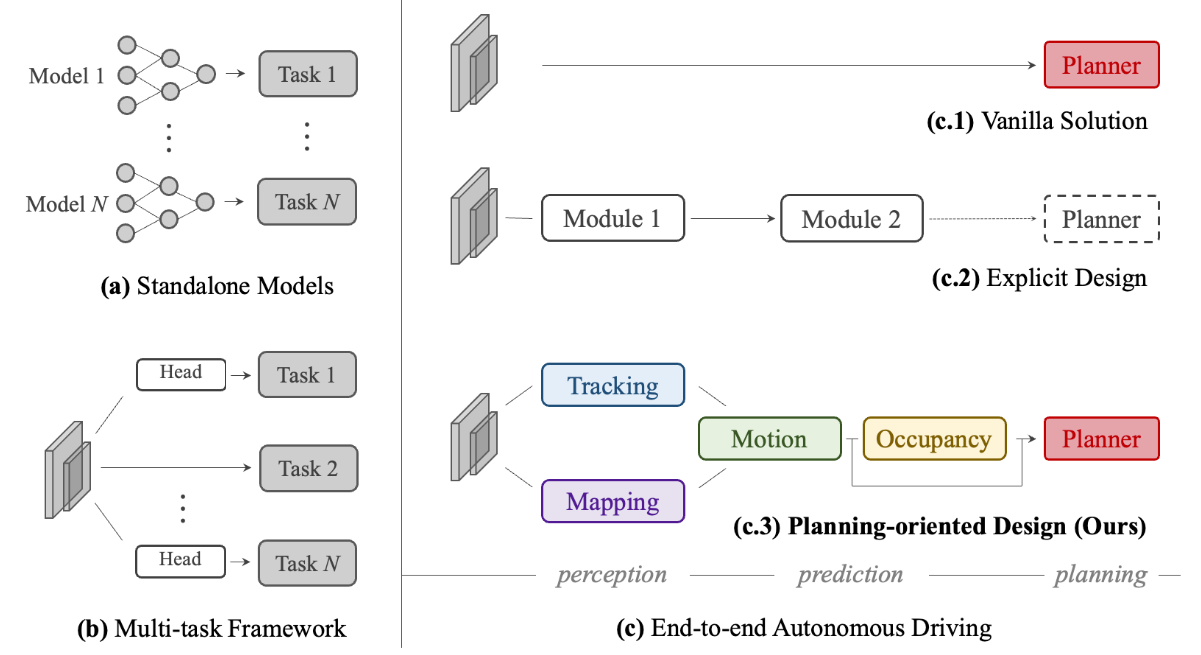
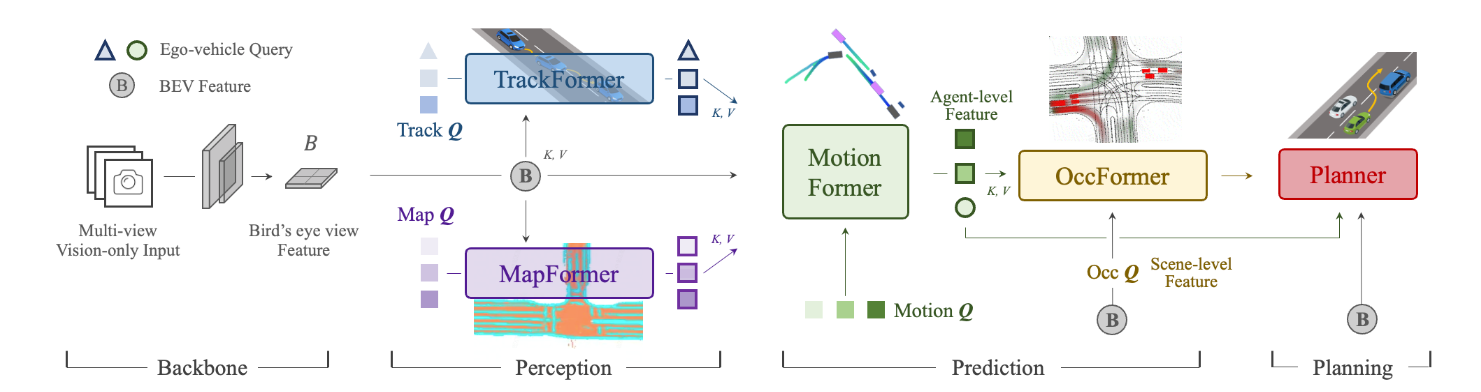

# UniAD: Planning-oriented Autonomous Driving 论文详解（详细版）

## 一、引言：自动驾驶框架的演进与规划导向的必要性

### 1.1 自动驾驶系统的模块化困境

现代自动驾驶系统通常由一系列串行任务组成：**感知（检测、跟踪、建图）→ 预测（运动预测、占用预测）→ 规划**。传统工业界往往为每个任务部署独立模型（图1a），这种设计虽然便于团队并行开发，但存在根本缺陷：

- **信息损失**：上游输出的抽象表示（如边界框）可能丢失下游需要的细节（如车辆朝向、遮挡程度）。
- **误差累积**：上游的检测误差会传递到预测，再放大到规划，导致最终决策失准。
- **优化目标不一致**：每个模块独立优化自己的指标，但各自最优的叠加未必使整体规划最优。

### 1.2 多任务学习（MTL）的尝试与不足

多任务学习通过共享骨干网络、接多个任务头来降低计算开销并促进特征共享（图1b）。然而，简单的MTL存在**负迁移**风险：不同任务的梯度可能冲突，导致某些任务性能下降。更重要的是，MTL只是“共享表示”，并未真正实现任务间的**逻辑协调**——各个任务头之间没有交互，预测模块无法利用感知查询中的丰富信息，规划模块也无法直接利用占用预测来避障。

### 1.3 端到端范式的兴起与两种路线

端到端自动驾驶试图将感知、预测、规划统一在一个可微网络中（图1c）。已有工作分为两类：

1. **直接规划（c.1）**：如Chauffeurnet等，直接从传感器输入预测控制信号或轨迹，不显式监督中间任务。这种方法可解释性差，安全性无法保证，在复杂城市场景中表现不佳。

2. **包含部分模块（c.2）**：如PnPNet、ViP3D、ST-P3等，它们联合了部分感知和预测任务，但往往**缺失某些关键组件**（例如PnPNet没有显式建图，ViP3D没有占用预测，ST-P3没有跟踪和建图）。由于任务不完整，这些方法难以充分建模动态场景中的交互。

### 1.4 UniAD的规划导向哲学

UniAD提出：**一个理想的端到端系统应该以规划为最终目标，精心选择和设计前置任务，使它们相互促进，共同服务于安全规划**（图1c.3）。这不仅仅是简单堆叠任务，而是需要：

- 确定哪些前置任务对规划是**必需的**（检测跟踪、在线建图、运动预测、占用预测）。
- 设计**查询接口**使这些任务之间能够灵活交换信息，而非独立输出。
- 通过联合优化避免误差累积和负迁移，实现全局最优。

---

## 二、UniAD总体架构

UniAD由四个基于Transformer解码器的模块和一个规划器组成，核心是**查询（Query）**作为连接各模块的接口。整体流程如图2所示：

1. **BEV特征提取**：多相机图像经过特征提取器和BEVFormer，生成统一的鸟瞰图特征 $ B $。
2. **TrackFormer**：使用检测查询和跟踪查询从 $ B $ 中检测并跟踪所有智能体（包括自车），输出智能体查询 $ Q_A $。
3. **MapFormer**：使用地图查询对道路元素（车道、分隔带、人行横道、可行驶区域）进行全景分割，输出地图查询 $ Q_M $。
4. **MotionFormer**：以 $ Q_A $ 和 $ Q_M $ 为条件，预测所有智能体的多模态未来轨迹，同时更新自车查询。
5. **OccFormer**：利用BEV特征 $ B $ 和智能体特征，预测未来多步的实例级占用网格。
6. **Planner**：利用MotionFormer输出的自车查询和导航命令生成规划轨迹，并通过占用预测进行避障优化。

所有模块均采用**Transformer解码器结构**，查询在模块间流动，实现端到端训练。

---

## 三、感知模块详解

### 3.1 TrackFormer：检测与跟踪

TrackFormer的目标是同时完成3D目标检测和多目标跟踪，且**不依赖非可微后处理**（如匈牙利匹配在推理时）。它借鉴了DETR和MOTR的设计，但做了适应自动驾驶的改进。

#### 3.1.1 查询设计

- **检测查询（Detection Queries）**：每一帧初始化一组可学习的查询，负责检测新出现的目标（“新生”目标）。
- **跟踪查询（Track Queries）**：从上一帧继承的查询，负责持续跟踪已存在的目标。这些查询通过自注意力机制与历史帧的跟踪查询交互，实现时序信息聚合。
- 检测查询和跟踪查询都通过交叉注意力从BEV特征 $ B $ 中提取目标信息。

#### 3.1.2 匹配与训练

训练时，检测查询与新生目标进行二分匹配，跟踪查询的匹配从上一帧继承。这种**共享匹配**策略使得跟踪结果在后续模块中保持一致，避免重新匹配引入的误差。

#### 3.1.3 自车查询

除了其他智能体，TrackFormer的查询集中包含一个特殊的**自车查询（ego-vehicle query）**，显式建模自车。这个查询会经过MotionFormer与周围智能体交互，最终用于规划。

**输出**：$ Q_A \in \mathbb{R}^{N_a \times D} $，包含 $ N_a $ 个有效智能体的查询特征，以及自车查询。

---

### 3.2 MapFormer：在线建图

MapFormer基于Panoptic SegFormer设计，将道路元素**稀疏地**表示为一组地图查询，而不是密集的BEV分割图。这种稀疏表示与查询驱动的下游任务天然兼容。

#### 3.2.1 地图元素定义

- **Things**：车道（lane）、分隔带（divider）、人行横道（crossing）——具有实例身份。
- **Stuff**：可行驶区域（drivable area）——无实例身份。

#### 3.2.2 查询与监督

- 初始化一组地图查询，通过交叉注意力从BEV特征 $ B $ 中提取道路信息。
- 每一层的输出都进行监督（类似DETR的辅助损失），但只有最后一层的更新查询 $ Q_M $ 传递给MotionFormer。

**输出**：$ Q_M \in \mathbb{R}^{M \times D} $，包含地图元素的语义和位置信息。

---

## 四、预测模块详解

### 4.1 MotionFormer：运动预测

MotionFormer是UniAD的核心预测模块，以场景中心的方式预测**所有智能体**的多模态未来轨迹，并特别考虑了端到端场景中上游感知的不确定性。

#### 4.1.1 输入与输出

- **输入**：智能体查询 $ Q_A $、地图查询 $ Q_M $。
- **输出**：每个智能体的 $ K $ 条可能轨迹 $ \{\hat{x}^{i,k} \in \mathbb{R}^{T \times 2} | i=1,\dots,N_a; k=1,\dots,K\} $，其中 $ T $ 为预测时长。

#### 4.1.2 逐层交互设计

MotionFormer由 $ N $ 层堆叠而成，每层执行三种并行的注意力交互：

1. **智能体-智能体交互**：
   $$
   Q_{a} = \text{MHCA}(\text{MHSA}(Q), Q_A)
   $$
   先对运动查询做自注意力（建模同一智能体不同模态间的关系），再与所有智能体查询做交叉注意力（建模智能体间的相互影响）。

2. **智能体-地图交互**：
   $$
   Q_{m} = \text{MHCA}(Q, Q_M)
   $$
   让运动查询关注静态道路结构，理解车道走向、交通规则等。

3. **智能体-目标点交互**（可变形注意力）：
   $$
   Q_{g} = \text{DeformAttn}(Q, \hat{x}^{l-1}_T, B)
   $$
   以上一层预测的轨迹终点 $ \hat{x}^{l-1}_T $ 为参考点，在BEV特征 $ B $ 上进行稀疏的可变形注意力，使查询能够感知终点附近的局部环境，从而细化预测轨迹。

三种交互的输出拼接后通过MLP生成**查询上下文** $ Q_{ctx} $，传递给下一层继续细化，或在最后一层解码为预测轨迹。

#### 4.1.3 运动查询的构成

每一层的输入运动查询由两部分组成：

$$
Q = Q_{ctx} + Q_{pos}
$$

- **查询上下文 $ Q_{ctx} $**：上一层的输出。
- **查询位置 $ Q_{pos} $**：融合了四种位置先验：
  $$
  Q_{pos} = \text{MLP}(\text{PE}(I_s)) + \text{MLP}(\text{PE}(I_a)) + \text{MLP}(\text{PE}(\hat{x}^0)) + \text{MLP}(\text{PE}(\hat{x}^{l-1}_T))
  $$
  - $ I_s $：**场景级锚点**（scene-level anchor），在全局坐标系下对轨迹终点进行k-means聚类得到，提供全局运动先验。
  - $ I_a $：**智能体级锚点**（agent-level anchor），在局部坐标系下聚类，捕捉个体意图。
  - $ \hat{x}^0 $：当前时刻的位置，提供个性化起点。
  - $ \hat{x}^{l-1}_T $：上一层预测的终点，作为动态锚点逐层细化。

#### 4.1.4 非线性优化（训练时）

由于端到端系统中上游感知可能存在位置和朝向误差，直接回归真值轨迹会导致不切实际的大曲率或加速度。UniAD在训练时采用**非线性平滑器**调整目标轨迹：

$$
\tilde{x}^* = \arg\min_x c(x, \tilde{x})
$$

其中代价函数 $ c $ 包含与真值的L2距离、终点距离以及一系列运动学正则项（jerk、曲率、曲率率、加速度、横向加速度）。优化通过multiple-shooting方法生成候选轨迹。**此优化仅在训练时用于生成更合理的监督目标，推理时不使用**。

---

### 4.2 OccFormer：占用预测

占用预测是另一个关键预测任务，它预测未来BEV网格中每个单元格是否被占用，并保留**实例身份**，为规划提供避障依据。

#### 4.2.1 设计动机

现有方法（如FIERY、BEVerse）通常使用RNN将BEV特征压缩为隐状态，再解码为未来占用，但这样**丢失了智能体级别的信息**，且需要复杂的后处理来生成实例级占用。OccFormer通过两个设计解决这一问题：

1. **像素-智能体交互**：在展开未来时，密集场景特征通过注意力机制从智能体特征中获取动态信息。
2. **实例级占用生成**：通过智能体特征与密集特征的矩阵乘法直接得到，无需后处理。

#### 4.2.2 模块结构

OccFormer由 $ T_o $ 个顺序块组成（$ T_o $ 为占用预测时长，通常小于运动预测时长 $ T $）。每个块接收上一层的密集特征 $ F^{t-1} $ 和智能体特征 $ G^t $，输出当前时刻的密集特征 $ F^t $。

**智能体特征 $ G^t $ 的构建**：
- 从MotionFormer的运动查询中做模态维度的**最大池化**，得到 $ Q_X \in \mathbb{R}^{N_a \times D} $（选择最可能的模态）。
- 与跟踪查询 $ Q_A $ 和当前时刻的位置嵌入 $ P_A $ 拼接，通过MLP得到 $ G^t $：
  $$
  G^t = \text{MLP}_t([Q_A, P_A, Q_X]), \quad t=1,\dots,T_o
  $$

**像素-智能体交互**：
- 将BEV特征 $ B $ 下采样到1/4分辨率作为 $ F^0 $。
- 每个块内部，将 $ F^{t-1} $ 进一步下采样到1/8得到 $ F^t_{ds} $，作为查询。
- 对 $ F^t_{ds} $ 先做自注意力（建模远距离空间依赖），再与智能体特征 $ G^t $ 做交叉注意力：
  $$
  D^t_{ds} = \text{MHCA}(\text{MHSA}(F^t_{ds}), G^t, \text{attn mask} = O^t_m)
  $$
- **注意力掩码 $ O^t_m $**：限制每个像素只关注占据它的智能体（类似Mask2Former的思想），确保像素-智能体的对应关系正确。掩码由额外的mask特征 $ M^t = \text{MLP}(G^t) $ 与 $ F^t_{ds} $ 相乘生成。

**实例级占用输出**：
- 将交互后的特征上采样回1/4分辨率，与输入 $ F^{t-1} $ 做残差连接得到 $ F^t $。
- 最终，通过卷积解码器上采样到原始BEV尺寸 $ F^t_{dec} \in \mathbb{R}^{C \times H \times W} $。
- 同时，将mask特征 $ M^t $ 通过MLP更新为占用特征 $ U^t \in \mathbb{R}^{N_a \times C} $。
- 实例级占用为：
  $$
  \hat{O}^t_A = U^t \cdot F^t_{dec}
  $$
  即每个智能体的占用特征是其在每个像素上的响应，通过矩阵乘法得到。

---

## 五、规划模块详解

### 5.1 规划查询的构建

- 导航命令（左转、右转、直行）被编码为三个可学习的嵌入（command embeddings）。
- MotionFormer输出的自车查询已经融合了周围智能体和地图的信息，并表达了多模态意图。将该查询与命令嵌入结合，形成**规划查询（plan query）**。

### 5.2 规划轨迹生成

- 规划查询首先通过交叉注意力关注BEV特征 $ B $，补充对周围环境的感知。
- 然后通过MLP解码为未来 $ T $ 个时刻的规划路点 $ \hat{\tau} \in \mathbb{R}^{T \times 2} $。

### 5.3 基于占用预测的避障优化（仅推理时）

为了进一步避免碰撞，UniAD在推理时使用牛顿法对规划轨迹进行微调：

$$
\tau^* = \arg\min_\tau f(\tau, \hat{\tau}, \hat{O})
$$

代价函数：

$$
f(\tau, \hat{\tau}, \hat{O}) = \lambda_{coord} \|\tau, \hat{\tau}\|_2 + \lambda_{obs} \sum_t D(\tau_t, \hat{O}_t)
$$

其中：

- $ \lambda_{coord} $ 和 $ \lambda_{obs} $ 是权重超参数。
- $ D(\tau_t, \hat{O}_t) $ 是碰撞项，计算轨迹点与占用网格的高斯距离：
  $$
  D(\tau_t, \hat{O}_t) = \sum_{(x,y) \in S} \frac{1}{\sigma\sqrt{2\pi}} \exp\left(-\frac{\|\tau_t - (x,y)\|_2^2}{2\sigma^2}\right)
  $$
  $ S $ 是轨迹点周围距离小于 $ d $ 的占用网格集合。
- 第一项拉近优化轨迹与原始预测的距离，第二项推开轨迹远离占用区域，实现安全与平滑的平衡。

---

## 六、训练策略与损失函数

### 6.1 两阶段训练

- **阶段一**：仅训练感知部分（TrackFormer和MapFormer），共6个epoch。这是为了让感知特征先稳定下来，为后续任务提供可靠输入。
- **阶段二**：端到端联合训练所有模块（感知、预测、规划），共20个epoch。实验表明两阶段训练比一次性端到端训练更稳定。

### 6.2 共享匹配

- 跟踪模块使用二分匹配为检测查询分配新生目标，跟踪查询继承上一帧的分配。
- **关键**：跟踪的匹配结果在MotionFormer和OccFormer中**复用**，确保同一智能体在整个时间线上（过去、现在、未来）保持一致身份，避免重新匹配带来的不一致性。

### 6.3 损失函数

各模块的损失如下（论文正文未完全展开，但在补充材料中有详细说明）：

- **TrackFormer**：检测分类损失（Focal Loss）+ 边界框回归损失（L1 Loss）+ 跟踪查询的匹配损失。
- **MapFormer**：全景分割损失（交叉熵 + Dice损失）。
- **MotionFormer**：轨迹回归损失（L2损失，对多模态取minADE形式）。
- **OccFormer**：占用分割损失（交叉熵 + Dice损失），包括实例级和场景级。
- **Planner**：轨迹回归损失（L2损失）+ 碰撞损失（可选，用于鼓励远离占用区域）。

---

## 七、实验与结果分析

### 7.1 联合消融实验（表2）

表2展示了逐步添加模块对性能的影响，是证明规划导向设计有效性的关键证据：

- **Exp.10（仅规划）**：L2误差1.131m，碰撞率0.773%。这是无中间监督的端到端规划基线。
- **Exp.11（规划+跟踪+建图+运动）**：加入感知和运动预测后，L2降至1.014m，碰撞率降至0.717%。运动预测的加入带来显著提升。
- **Exp.12（全模块）**：再加入占用预测后，L2降至1.004m，碰撞率大幅降至**0.430%**。这说明占用预测为规划提供了关键的避障信息。
- 对比**Exp.0（朴素MTL）**：所有任务独立头，共享骨干，其规划L2为1.154m，碰撞率0.941%。UniAD的规划导向设计将碰撞率降低了**一半以上**，L2误差降低约13%。

此外，感知任务之间也存在协同：同时训练跟踪和建图（Exp.3）相比单独训练跟踪（Exp.1）在跟踪指标上几乎无损，说明无负迁移。运动预测和占用预测联合（Exp.9）相比单独运动预测（Exp.6）进一步降低了minADE和minFDE。

### 7.2 模块级结果

- **多目标跟踪**：UniAD的AMOTA达到0.359，超过MUTR3D（0.294）和ViP3D（0.217），且IDS（身份切换）数量最低（906），表明时序一致性更好。
- **在线建图**：车道IoU 31.3%，远高于BEVFormer（23.9%），说明查询式建图对车道结构的学习更有效。
- **运动预测**：minADE 0.71m，相比PnPNet-vision（1.15m）降低38.3%，相比ViP3D（2.05m）降低65.4%，证明场景中心式预测和查询交互设计的优越性。
- **占用预测**：IoU-near 63.4%，超过FIERY（59.4%）和BEVerse（61.4%），特别是在近距离区域（对规划更关键）提升明显。
- **规划**：L2误差1.03m，碰撞率0.31%，显著优于ST-P3（L2 2.11m，碰撞率0.71%），甚至超过一些LiDAR方法（如FF、EO），证明了纯视觉方案通过任务协调也能达到高安全性。

### 7.3 消融实验细节

- **MotionFormer组件**（表8）：场景级锚点贡献最大（minADE从0.844降至0.768），说明全局运动先验很重要；目标点交互、自车查询、非线性优化均有正向作用。
- **OccFormer组件**（表9）：注意力掩码是关键，没有掩码的交叉注意力反而略差于无注意力基线；复用mask特征生成实例级占用进一步提升VPQ。
- **Planner组件**（表10）：BEV注意力、碰撞损失、占用优化三者结合才能显著降低碰撞率（从1.64%降至1.05%）。

### 7.4 定性分析

论文展示了一个复杂场景的可视化（图3），所有任务的输出在BEV和图像视图中一致，自车正在避让前方黑色车辆。此外，补充材料中还展示了**规划导向设计的鲁棒性**：即使上游跟踪出现误差（如目标朝向偏差或漏检），下游规划仍能产生合理轨迹，体现了查询表示的容错能力。失败案例主要出现在长尾目标（如大卡车、拖车）上。

---

## 八、创新点与贡献总结

1. **规划导向的端到端框架**：首次将检测、跟踪、建图、运动预测、占用预测和规划统一在一个网络中，并明确以规划为最终优化目标。
2. **查询接口设计**：所有任务通过查询连接，实现了灵活的信息交换和联合优化，避免了传统模块间的信息瓶颈。
3. **场景中心式多智能体预测**：MotionFormer以场景为中心一次预测所有智能体的多模态轨迹，相比逐智能体预测更高效且能建模交互。
4. **实例级占用预测**：OccFormer通过像素-智能体交互和矩阵乘法生成实例级占用，无需后处理，为规划提供精细的避障信息。
5. **训练策略创新**：两阶段训练、共享匹配、非线性轨迹平滑等设计确保了端到端训练的稳定性和合理性。
6. **显著的性能提升**：在nuScenes上，规划碰撞率相对ST-P3降低56.3%，运动预测误差相对ViP3D降低65.4%，验证了方法的有效性。

---

## 九、局限性与未来方向

- **计算开销大**：多个任务联合训练、时序历史输入导致训练和推理成本高，难以直接部署到车载芯片。未来需要研究模型轻量化或任务剪枝。
- **任务范围有限**：尚未包含深度估计、行为预测等任务，未来可探索更多任务的整合方式。
- **长尾问题**：大卡车、拖车等罕见目标仍可能导致失败，需要增强数据多样性或引入更好的表示。
- **评测仍基于开环**：虽然规划碰撞率降低，但nuScenes的规划评测仍是开环的，未在闭环仿真中验证。后续工作需要在闭环环境中进一步测试。

---

## 十、影响与启示

UniAD的发表掀起了端到端自动驾驶的研究热潮，其规划导向的哲学和查询式设计被后续大量工作借鉴（如VAD、SparseDrive、GenAD等）。它证明了**任务协调比简单堆叠更重要**，为构建安全、可解释的自动驾驶系统提供了新范式。同时，它也揭示了纯视觉方案在复杂城市场景中的潜力，推动了行业对端到端方案的关注。